# Analisis Data Gempa BMKG

**Nama:** Vyola Cecilia Potto  
**NIM:** E1E124079  
**Mata Kuliah:** Data Science 2  

## Dataset
Data Gempa BMKG

## Sumber Data
BMKG — Badan Meteorologi, Klimatologi, dan Geofisika

## Deskripsi Proyek
Proyek ini bertujuan untuk melakukan proses data wrangling,
data assessing, data cleaning, exploratory data analysis (EDA),
visualisasi, dan analisis lanjutan terhadap data gempa bumi
yang diperoleh dari BMKG.

**Business Questions yang saya pilih**
BQ1 — Basic
Bagaimana karakteristik dan distribusi magnitudo gempa yang tercatat dalam dataset BMKG?

BQ2 — Analysis
Apakah terdapat hubungan antara kedalaman gempa dan magnitudo gempa?

BQ3 — Analysis

Bagaimana perbedaan karakteristik gempa berdasarkan wilayah, khususnya dari sisi magnitudo, kedalaman, dan jumlah kejadian?

BQ4 — AI / Machine Learning

Apakah terdapat kejadian gempa yang memiliki karakteristik tidak biasa (anomaly) berdasarkan magnitudo dan kedalaman?

# Business Questions

## BQ1 — Basic Analysis

Bagaimana karakteristik dan distribusi magnitudo gempa yang
tercatat dalam dataset BMKG?

### Metode
- Statistik deskriptif
- Histogram
- Boxplot


## BQ2 — Analysis

Apakah terdapat hubungan antara kedalaman gempa dan magnitudo gempa?

### Metode
- Correlation analysis
- Scatter plot
- Regression/trend line


## BQ3 — Analysis

Bagaimana perbedaan karakteristik gempa berdasarkan wilayah,
khususnya dari sisi magnitudo, kedalaman, dan jumlah kejadian?

### Metode
- Grouping dan aggregation
- Perbandingan statistik
- Bar chart
- Heatmap jika relevan


## BQ4 — AI / Machine Learning

Apakah terdapat kejadian gempa yang memiliki karakteristik
tidak biasa (anomaly) berdasarkan magnitudo dan kedalaman?

### Metode
- Isolation Forest
- Anomaly detection
- Visualisasi hasil anomaly detection

Kenapa saya memilih 4 ini?

Karena nanti alur presentasinya enak:

BQ1 → "Seperti apa datanya?"

⬇️

BQ2 → "Apakah dua variabel penting saling berhubungan?"

⬇️

BQ3 → "Apakah karakteristiknya berbeda antarwilayah?"

⬇️

BQ4 → "Bisakah machine learning menemukan observasi yang tidak biasa?"

IMPOR PACKAGE

In [1]:
# ============================================
# IMPORT PACKAGES
# ============================================

import json
import os
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

print("All packages imported successfully!")

All packages imported successfully!


MARKDOWN

# Data Loading

Dataset gempa BMKG yang telah diperoleh dalam format JSON akan dimuat ke dalam Google Colab.

Pada tahap ini, data akan ditampilkan dalam bentuk struktur JSON terlebih dahulu untuk memastikan struktur data dapat dibaca dengan benar sebelum dilakukan proses data wrangling.

In [2]:
# ============================================
# MENGAMBIL DATA GEMPA BMKG
# ============================================

import requests

url = "https://data.bmkg.go.id/DataMKG/TEWS/gempaterkini.json"

response = requests.get(url)

print("Status code:", response.status_code)
print("Ukuran data:", len(response.content), "bytes")

Status code: 200
Ukuran data: 4137 bytes


In [3]:
# ============================================
# LOAD DATA JSON BMKG
# ============================================

data = response.json()

print("JSON berhasil dimuat!")
print("Struktur utama:", data.keys())

JSON berhasil dimuat!
Struktur utama: dict_keys(['Infogempa'])


In [4]:
# ============================================
# CHECK STRUKTUR DATA BMKG
# ============================================

gempa = data["Infogempa"]["gempa"]

print("Jumlah data gempa:", len(gempa))
print("\nKolom yang tersedia:")
print(gempa[0].keys())

print("\nContoh 1 data:")
print(gempa[0])

Jumlah data gempa: 15

Kolom yang tersedia:
dict_keys(['Tanggal', 'Jam', 'DateTime', 'Coordinates', 'Lintang', 'Bujur', 'Magnitude', 'Kedalaman', 'Wilayah', 'Potensi'])

Contoh 1 data:
{'Tanggal': '04 Okt 2026', 'Jam': '06:37:31 WIB', 'DateTime': '2026-10-03T23:37:31+00:00', 'Coordinates': '4.56,94.97', 'Lintang': '4.56 LU', 'Bujur': '94.97 BT', 'Magnitude': '5.9', 'Kedalaman': '26 km', 'Wilayah': '68 km BaratDaya CALANG-ACEHJAYA', 'Potensi': 'Tidak berpotensi tsunami'}


In [5]:
# ============================================
# DATA WRANGLING - MEMBUAT DATAFRAME MENTAH
# ============================================

df_raw = pd.DataFrame(gempa)

print("DataFrame berhasil dibuat!")
print("Jumlah baris :", df_raw.shape[0])
print("Jumlah kolom :", df_raw.shape[1])

df_raw.head()

DataFrame berhasil dibuat!
Jumlah baris : 15
Jumlah kolom : 10


,Tanggal,Jam,DateTime,Coordinates,Lintang,Bujur,Magnitude,Kedalaman,Wilayah,Potensi
0,04 Okt 2026,06:37:31 WIB,2026-10-03T23:37:31+00:00,"4.56,94.97",4.56 LU,94.97 BT,5.9,26 km,68 km BaratDaya CALANG-ACEHJAYA,Tidak berpotensi tsunami
1,04 Okt 2026,05:55:52 WIB,2026-10-03T22:55:52+00:00,"-9.70,118.92",9.70 LS,118.92 BT,6.1,10 km,14 km BaratDaya KODI-SUMBABARATDAYA-NTT,Tidak berpotensi tsunami
2,01 Okt 2026,21:20:00 WIB,2026-10-01T14:20:00+00:00,"-7.07,120.80",7.07 LS,120.80 BT,5.1,10 km,111 km Tenggara SELAYAR-SULSEL,Tidak berpotensi tsunami
3,22 Sep 2026,06:48:13 WIB,2026-09-21T23:48:13+00:00,"4.74,125.30",4.74 LU,125.30 BT,5.2,10 km,127 km BaratLaut TAHUNA-KEP.SANGIHE-SULUT,Tidak berpotensi tsunami
4,21 Sep 2026,14:31:07 WIB,2026-09-21T07:31:07+00:00,"-0.70,122.45",0.70 LS,122.45 BT,5.3,10 km,26 km BaratDaya PULAUPUAH-SULTENG,Tidak berpotensi tsunami


In [6]:
# ============================================
# DATA ASSESSING 1
# STRUKTUR DAN TIPE DATA
# ============================================

print("=== INFO DATASET ===")
df_raw.info()

print("\n=== TIPE DATA SETIAP KOLOM ===")
print(df_raw.dtypes)

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Tanggal      15 non-null     object
 1   Jam          15 non-null     object
 2   DateTime     15 non-null     object
 3   Coordinates  15 non-null     object
 4   Lintang      15 non-null     object
 5   Bujur        15 non-null     object
 6   Magnitude    15 non-null     object
 7   Kedalaman    15 non-null     object
 8   Wilayah      15 non-null     object
 9   Potensi      15 non-null     object
dtypes: object(10)
memory usage: 1.3+ KB

=== TIPE DATA SETIAP KOLOM ===
Tanggal        object
Jam            object
DateTime       object
Coordinates    object
Lintang        object
Bujur          object
Magnitude      object
Kedalaman      object
Wilayah        object
Potensi        object
dtype: object


In [7]:
# ============================================
# DATA ASSESSING 2
# MISSING VALUE
# ============================================

missing = df_raw.isnull().sum()

print("=== JUMLAH MISSING VALUE ===")
print(missing)

print("\n=== TOTAL MISSING VALUE ===")
print("Total:", missing.sum())

=== JUMLAH MISSING VALUE ===
Tanggal        0
Jam            0
DateTime       0
Coordinates    0
Lintang        0
Bujur          0
Magnitude      0
Kedalaman      0
Wilayah        0
Potensi        0
dtype: int64

=== TOTAL MISSING VALUE ===
Total: 0


In [8]:
# ============================================
# DATA ASSESSING 3
# DUPLICATE DATA
# ============================================

duplicate_count = df_raw.duplicated().sum()

print("=== DUPLICATE DATA ===")
print("Jumlah baris duplikat:", duplicate_count)

print("\n=== STATUS ===")
if duplicate_count == 0:
    print("Tidak ditemukan data duplikat.")
else:
    print("Ditemukan data duplikat.")
    display(df_raw[df_raw.duplicated(keep=False)])

=== DUPLICATE DATA ===
Jumlah baris duplikat: 0

=== STATUS ===
Tidak ditemukan data duplikat.


In [9]:
# ============================================
# DATA ASSESSING 4
# NILAI UNIK / KATEGORIKAL
# ============================================

print("=== NILAI UNIK POTENSI ===")
print(df_raw["Potensi"].value_counts())

print("\n=== JUMLAH WILAYAH UNIK ===")
print(df_raw["Wilayah"].nunique())

print("\n=== DAFTAR WILAYAH ===")
print(df_raw["Wilayah"].unique())

=== NILAI UNIK POTENSI ===
Potensi
Tidak berpotensi tsunami    15
Name: count, dtype: int64

=== JUMLAH WILAYAH UNIK ===
15

=== DAFTAR WILAYAH ===
['68 km BaratDaya CALANG-ACEHJAYA'
 '14 km BaratDaya KODI-SUMBABARATDAYA-NTT'
 '111 km Tenggara SELAYAR-SULSEL'
 '127 km BaratLaut TAHUNA-KEP.SANGIHE-SULUT'
 '26 km BaratDaya PULAUPUAH-SULTENG'
 '34 km TimurLaut RUTENG-MANGGARAI-NTT' '33 km TimurLaut SARMI-PAPUA'
 '198 km BaratDaya BAYAH-BANTEN' '118 km BaratLaut JAILOLO-MALUT'
 '42 km TimurLaut PULAUDOI-MALUT' '186 km BaratDaya BAYAH-BANTEN'
 '156 km Tenggara KAB-MALANG-JATIM' '227 km BaratLaut TANIMBAR'
 '6 km Tenggara KEPSERIBU-DKI' '166 km TimurLaut MALUKUBRTDAYA']


In [10]:
# ============================================
# DATA ASSESSING 5
# CEK NILAI NUMERIK
# ============================================

print("=== MAGNITUDE ===")
print(df_raw["Magnitude"].value_counts().sort_index())

print("\n=== KEDALAMAN ===")
print(df_raw["Kedalaman"].value_counts().sort_index())

=== MAGNITUDE ===
Magnitude
5.1    4
5.2    3
5.3    2
5.6    1
5.9    2
6.1    1
6.2    2
Name: count, dtype: int64

=== KEDALAMAN ===
Kedalaman
10 km     9
124 km    1
143 km    1
145 km    1
24 km     1
26 km     1
376 km    1
Name: count, dtype: int64


In [11]:
# ============================================
# DATA ASSESSING 6
# CEK DATETIME DAN KOORDINAT
# ============================================

print("=== DATETIME ===")
print(df_raw["DateTime"])

print("\n=== LINTANG ===")
print(df_raw["Lintang"])

print("\n=== BUJUR ===")
print(df_raw["Bujur"])

=== DATETIME ===
0     2026-10-03T23:37:31+00:00
1     2026-10-03T22:55:52+00:00
2     2026-10-01T14:20:00+00:00
3     2026-09-21T23:48:13+00:00
4     2026-09-21T07:31:07+00:00
5     2026-09-21T01:41:37+00:00
6     2026-09-19T04:18:36+00:00
7     2026-09-18T14:36:17+00:00
8     2026-09-17T06:20:53+00:00
9     2026-09-14T10:58:04+00:00
10    2026-09-14T09:27:39+00:00
11    2026-09-14T01:42:08+00:00
12    2026-09-12T06:14:33+00:00
13    2026-09-11T21:23:56+00:00
14    2026-09-11T11:56:24+00:00
Name: DateTime, dtype: object

=== LINTANG ===
0     4.56 LU
1     9.70 LS
2     7.07 LS
3     4.74 LU
4     0.70 LS
5     8.33 LS
6     1.60 LS
7     8.64 LS
8     1.35 LU
9     2.52 LU
10    8.54 LS
11    9.52 LS
12    6.03 LS
13    5.81 LS
14    7.44 LS
Name: Lintang, dtype: object

=== BUJUR ===
0      94.97 BT
1     118.92 BT
2     120.80 BT
3     125.30 BT
4     122.45 BT
5     120.59 BT
6     138.88 BT
7     105.74 BT
8     126.44 BT
9     128.09 BT
10    105.78 BT
11    112.85 BT
12    130.

DATA CLEANING

In [12]:
# ============================================
# DATA CLEANING 1
# KONVERSI DATA NUMERIK
# ============================================

df_clean = df_raw.copy()

# Konversi Magnitude menjadi numerik
df_clean["Magnitude"] = pd.to_numeric(
    df_clean["Magnitude"],
    errors="coerce"
)

# Hapus teks "km" dari Kedalaman lalu ubah menjadi numerik
df_clean["Kedalaman"] = (
    df_clean["Kedalaman"]
    .str.replace(" km", "", regex=False)
    .astype(float)
)

print("Konversi Magnitude dan Kedalaman selesai!")

print("\nTipe data setelah konversi:")
print(df_clean[["Magnitude", "Kedalaman"]].dtypes)

Konversi Magnitude dan Kedalaman selesai!

Tipe data setelah konversi:
Magnitude    float64
Kedalaman    float64
dtype: object


In [13]:
# ============================================
# DATA CLEANING 2
# KONVERSI DATETIME
# ============================================

df_clean["DateTime"] = pd.to_datetime(
    df_clean["DateTime"],
    errors="coerce",
    utc=True
)

print("Konversi DateTime selesai!")
print("\nTipe data:")
print(df_clean["DateTime"].dtype)

print("\nContoh data:")
print(df_clean["DateTime"].head())

Konversi DateTime selesai!

Tipe data:
datetime64[ns, UTC]

Contoh data:
0   2026-10-03 23:37:31+00:00
1   2026-10-03 22:55:52+00:00
2   2026-10-01 14:20:00+00:00
3   2026-09-21 23:48:13+00:00
4   2026-09-21 07:31:07+00:00
Name: DateTime, dtype: datetime64[ns, UTC]


In [14]:
# ============================================
# DATA CLEANING 3
# KONVERSI LINTANG DAN BUJUR
# ============================================

# Lintang:
# LU = positif
# LS = negatif
df_clean["Latitude"] = (
    df_clean["Lintang"]
    .str.replace(" LU", "", regex=False)
    .str.replace(" LS", "", regex=False)
    .astype(float)
)

df_clean.loc[
    df_clean["Lintang"].str.contains("LS", na=False),
    "Latitude"
] *= -1

# Bujur:
# BT = positif
df_clean["Longitude"] = (
    df_clean["Bujur"]
    .str.replace(" BT", "", regex=False)
    .astype(float)
)

print("Konversi koordinat selesai!")

print("\nContoh hasil:")
display(
    df_clean[["Lintang", "Bujur", "Latitude", "Longitude"]].head()
)

Konversi koordinat selesai!

Contoh hasil:


,Lintang,Bujur,Latitude,Longitude
0,4.56 LU,94.97 BT,4.56,94.97
1,9.70 LS,118.92 BT,-9.70,118.92
2,7.07 LS,120.80 BT,-7.07,120.80
3,4.74 LU,125.30 BT,4.74,125.30
4,0.70 LS,122.45 BT,-0.70,122.45


In [15]:
# ============================================
# DATA CLEANING 4
# FINAL CLEANING CHECK
# ============================================

print("=== TIPE DATA SETELAH CLEANING ===")
print(df_clean.dtypes)

print("\n=== MISSING VALUE SETELAH CLEANING ===")
print(df_clean.isnull().sum())

print("\n=== JUMLAH DUPLIKAT SETELAH CLEANING ===")
print(df_clean.duplicated().sum())

=== TIPE DATA SETELAH CLEANING ===
Tanggal                     object
Jam                         object
DateTime       datetime64[ns, UTC]
Coordinates                 object
Lintang                     object
Bujur                       object
Magnitude                  float64
Kedalaman                  float64
Wilayah                     object
Potensi                     object
Latitude                   float64
Longitude                  float64
dtype: object

=== MISSING VALUE SETELAH CLEANING ===
Tanggal        0
Jam            0
DateTime       0
Coordinates    0
Lintang        0
Bujur          0
Magnitude      0
Kedalaman      0
Wilayah        0
Potensi        0
Latitude       0
Longitude      0
dtype: int64

=== JUMLAH DUPLIKAT SETELAH CLEANING ===
0


In [16]:
# ============================================
# DATA ASSESSING SETELAH CLEANING
# ============================================

print("============================================")
print("ASSESSING DATASET SETELAH CLEANING")
print("============================================")

print("\n=== UKURAN DATASET ===")
print("Jumlah baris :", df_clean.shape[0])
print("Jumlah kolom :", df_clean.shape[1])

print("\n=== TIPE DATA ===")
print(df_clean.dtypes)

print("\n=== MISSING VALUE ===")
print(df_clean.isnull().sum())

print("\n=== DUPLICATE ===")
print("Jumlah duplicate:", df_clean.duplicated().sum())

print("\n=== STATISTIK NUMERIK ===")
display(df_clean[[
    "Magnitude",
    "Kedalaman",
    "Latitude",
    "Longitude"
]].describe())

ASSESSING DATASET SETELAH CLEANING

=== UKURAN DATASET ===
Jumlah baris : 15
Jumlah kolom : 12

=== TIPE DATA ===
Tanggal                     object
Jam                         object
DateTime       datetime64[ns, UTC]
Coordinates                 object
Lintang                     object
Bujur                       object
Magnitude                  float64
Kedalaman                  float64
Wilayah                     object
Potensi                     object
Latitude                   float64
Longitude                  float64
dtype: object

=== MISSING VALUE ===
Tanggal        0
Jam            0
DateTime       0
Coordinates    0
Lintang        0
Bujur          0
Magnitude      0
Kedalaman      0
Wilayah        0
Potensi        0
Latitude       0
Longitude      0
dtype: int64

=== DUPLICATE ===
Jumlah duplicate: 0

=== STATISTIK NUMERIK ===


,Magnitude,Kedalaman,Latitude,Longitude
count,15.00000,15.000000,15.000000,15.000000
mean,5.50000,61.866667,-4.014000,119.142667
std,0.43589,101.053640,5.277629,11.799027
min,5.10000,10.000000,-9.700000,94.970000
25%,5.15000,10.000000,-8.435000,109.705000
50%,5.30000,10.000000,-6.030000,120.800000
75%,5.90000,75.000000,0.325000,127.265000
max,6.20000,376.000000,4.740000,138.880000


# Exploratory Data Analysis (EDA)

## BQ1 — Karakteristik dan Distribusi Magnitudo

**Business Question:**

Bagaimana karakteristik dan distribusi magnitudo gempa yang tercatat dalam dataset BMKG?

Analisis dilakukan menggunakan statistik deskriptif dan visualisasi distribusi magnitudo untuk memahami nilai tengah, penyebaran, nilai minimum, maksimum, serta pola distribusi data.

In [17]:
# ============================================
# BQ1 — STATISTIK DESKRIPTIF MAGNITUDE
# ============================================

magnitude_stats = df_clean["Magnitude"].describe()

print("=== STATISTIK DESKRIPTIF MAGNITUDE ===")
display(magnitude_stats)

print("\n=== FREKUENSI MAGNITUDE ===")
display(
    df_clean["Magnitude"]
    .value_counts()
    .sort_index()
)

=== STATISTIK DESKRIPTIF MAGNITUDE ===


,Magnitude
count,15.00000
mean,5.50000
std,0.43589
min,5.10000
25%,5.15000
50%,5.30000
75%,5.90000
max,6.20000



=== FREKUENSI MAGNITUDE ===


,count
Magnitude,
5.1,4
5.2,3
5.3,2
5.6,1
5.9,2
6.1,1
6.2,2


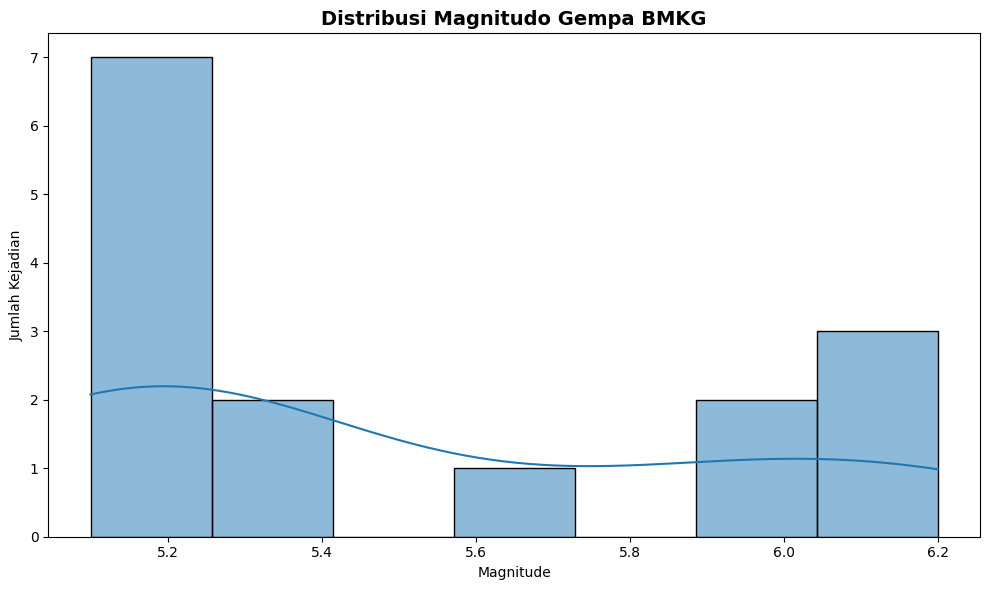

In [18]:
# ============================================
# BQ1 — HISTOGRAM MAGNITUDE
# ============================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_clean,
    x="Magnitude",
    bins=7,
    kde=True
)

plt.title(
    "Distribusi Magnitudo Gempa BMKG",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Magnitude")
plt.ylabel("Jumlah Kejadian")

plt.tight_layout()
plt.show()

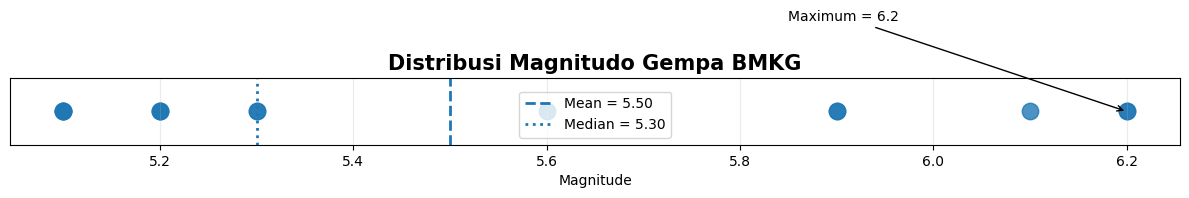

In [19]:
# ============================================
# BQ1 — MAGNITUDE DOT PLOT
# ============================================

magnitude_data = df_clean["Magnitude"].sort_values().reset_index(drop=True)

plt.figure(figsize=(12, 4.5))

# Titik setiap kejadian
plt.scatter(
    magnitude_data,
    np.zeros(len(magnitude_data)),
    s=140,
    alpha=0.8
)

# Garis mean
plt.axvline(
    magnitude_data.mean(),
    linestyle="--",
    linewidth=2,
    label=f"Mean = {magnitude_data.mean():.2f}"
)

# Garis median
plt.axvline(
    magnitude_data.median(),
    linestyle=":",
    linewidth=2,
    label=f"Median = {magnitude_data.median():.2f}"
)

# Anotasi nilai maksimum
max_value = magnitude_data.max()

plt.annotate(
    f"Maximum = {max_value:.1f}",
    xy=(max_value, 0),
    xytext=(max_value - 0.35, 0.15),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

plt.yticks([])
plt.xlabel("Magnitude")
plt.title(
    "Distribusi Magnitudo Gempa BMKG",
    fontsize=15,
    fontweight="bold"
)

plt.legend()
plt.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

### Interpretasi BQ1

Berdasarkan 15 kejadian gempa pada dataset BMKG, magnitudo memiliki nilai minimum sebesar **5,1** dan maksimum sebesar **6,2**. Nilai rata-rata magnitudo adalah **5,50**, sedangkan median sebesar **5,3**.

Magnitudo yang paling sering muncul adalah **5,1**, yaitu sebanyak **4 kejadian**. Selain itu, terdapat beberapa kejadian dengan magnitudo yang lebih tinggi, termasuk **2 kejadian dengan magnitudo 6,2** sebagai nilai maksimum dalam dataset.

Perbedaan antara nilai mean (**5,50**) dan median (**5,3**) menunjukkan bahwa beberapa kejadian dengan magnitudo lebih tinggi meningkatkan nilai rata-rata. Secara keseluruhan, distribusi magnitudo dalam dataset didominasi oleh kejadian pada kisaran **5,1–5,3**, meskipun terdapat beberapa kejadian dengan magnitudo yang lebih tinggi.

Hasil ini hanya menggambarkan **15 kejadian gempa** yang terdapat dalam dataset BMKG yang digunakan, sehingga belum dapat dianggap sebagai gambaran seluruh kejadian gempa di Indonesia.

# BQ2 — Hubungan Kedalaman dan Magnitudo

**Business Question:**

Apakah terdapat hubungan antara kedalaman gempa dan magnitudo gempa?

Analisis dilakukan dengan membandingkan variabel `Kedalaman` dan `Magnitude` menggunakan korelasi dan scatter plot. Analisis ini bertujuan untuk melihat apakah perubahan kedalaman gempa cenderung diikuti oleh perubahan magnitudo pada dataset.

In [20]:
# ============================================
# BQ2 — KORELASI KEDALAMAN DAN MAGNITUDE
# ============================================

correlation = df_clean["Kedalaman"].corr(
    df_clean["Magnitude"]
)

print("=== KORELASI KEDALAMAN DAN MAGNITUDE ===")
print(f"Pearson correlation: {correlation:.3f}")

=== KORELASI KEDALAMAN DAN MAGNITUDE ===
Pearson correlation: 0.469


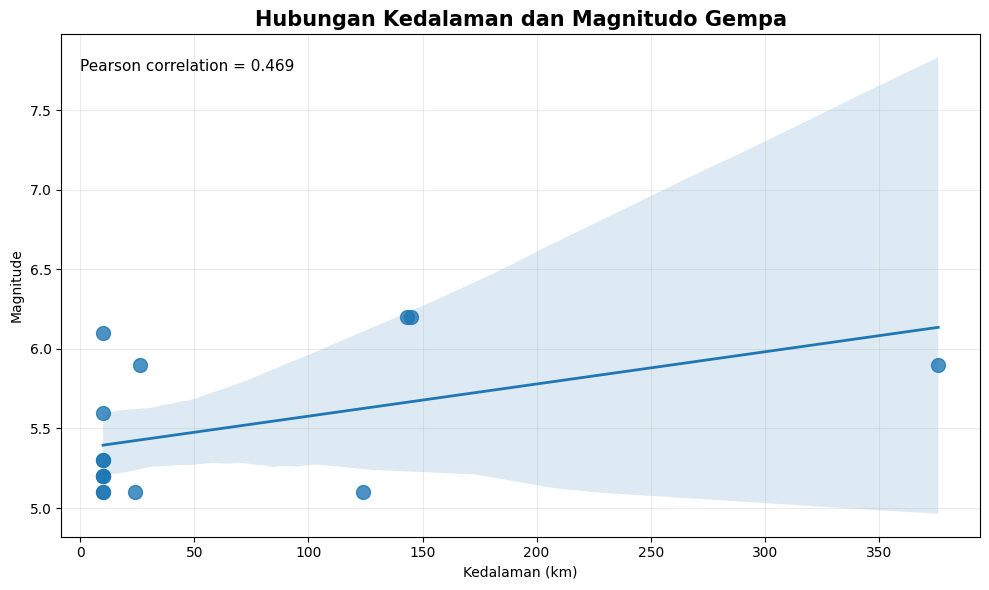

In [21]:
# ============================================
# BQ2 — SCATTER PLOT + TREND LINE
# ============================================

plt.figure(figsize=(10, 6))

sns.regplot(
    data=df_clean,
    x="Kedalaman",
    y="Magnitude",
    scatter_kws={
        "s": 100,
        "alpha": 0.8
    },
    line_kws={
        "linewidth": 2
    }
)

plt.title(
    "Hubungan Kedalaman dan Magnitudo Gempa",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Kedalaman (km)")
plt.ylabel("Magnitude")

plt.text(
    0.02,
    0.95,
    f"Pearson correlation = {correlation:.3f}",
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment="top"
)

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [22]:
# ============================================
# BQ2 — PERBANDINGAN PEARSON DAN SPEARMAN
# ============================================

pearson_corr = df_clean["Kedalaman"].corr(
    df_clean["Magnitude"],
    method="pearson"
)

spearman_corr = df_clean["Kedalaman"].corr(
    df_clean["Magnitude"],
    method="spearman"
)

print("=== PERBANDINGAN KORELASI ===")
print(f"Pearson  : {pearson_corr:.3f}")
print(f"Spearman : {spearman_corr:.3f}")

=== PERBANDINGAN KORELASI ===
Pearson  : 0.469
Spearman : 0.411


In [23]:
# ============================================
# BQ2 — IDENTIFIKASI DATA KEDALAMAN EKSTREM
# ============================================

print("=== DATA DIURUTKAN BERDASARKAN KEDALAMAN ===")

display(
    df_clean[
        ["DateTime", "Kedalaman", "Magnitude", "Wilayah"]
    ]
    .sort_values("Kedalaman", ascending=False)
    .reset_index(drop=True)
)

=== DATA DIURUTKAN BERDASARKAN KEDALAMAN ===


,DateTime,Kedalaman,Magnitude,Wilayah
0,2026-09-11 21:23:56+00:00,376.0,5.9,6 km Tenggara KEPSERIBU-DKI
1,2026-09-14 10:58:04+00:00,145.0,6.2,42 km TimurLaut PULAUDOI-MALUT
2,2026-09-11 11:56:24+00:00,143.0,6.2,166 km TimurLaut MALUKUBRTDAYA
3,2026-09-12 06:14:33+00:00,124.0,5.1,227 km BaratLaut TANIMBAR
4,2026-10-03 23:37:31+00:00,26.0,5.9,68 km BaratDaya CALANG-ACEHJAYA
5,2026-09-17 06:20:53+00:00,24.0,5.1,118 km BaratLaut JAILOLO-MALUT
6,2026-10-03 22:55:52+00:00,10.0,6.1,14 km BaratDaya KODI-SUMBABARATDAYA-NTT
7,2026-09-19 04:18:36+00:00,10.0,5.1,33 km TimurLaut SARMI-PAPUA
8,2026-09-21 01:41:37+00:00,10.0,5.3,34 km TimurLaut RUTENG-MANGGARAI-NTT
9,2026-09-21 07:31:07+00:00,10.0,5.3,26 km BaratDaya PULAUPUAH-SULTENG


In [24]:
# ============================================
# BQ2 — KATEGORI KEDALAMAN
# ============================================

df_clean["Kategori_Kedalaman"] = pd.cut(
    df_clean["Kedalaman"],
    bins=[-1, 10, 100, float("inf")],
    labels=["≤ 10 km", "11–100 km", "> 100 km"]
)

print("=== JUMLAH GEMPA BERDASARKAN KATEGORI KEDALAMAN ===")

display(
    df_clean["Kategori_Kedalaman"]
    .value_counts()
    .sort_index()
)

=== JUMLAH GEMPA BERDASARKAN KATEGORI KEDALAMAN ===


,count
Kategori_Kedalaman,
≤ 10 km,9
11–100 km,2
> 100 km,4


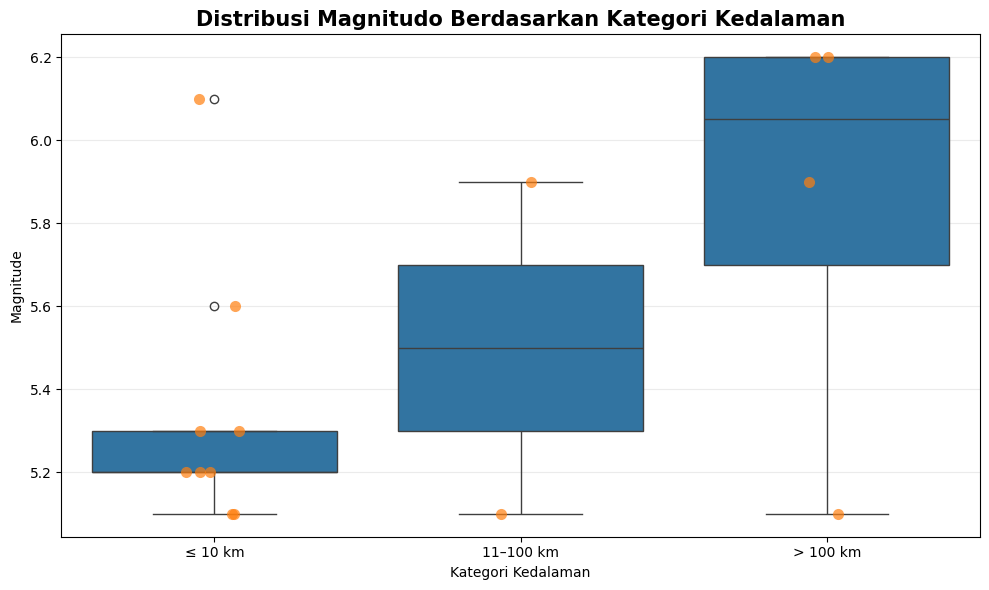

In [25]:
# ============================================
# BQ2 — MAGNITUDE BERDASARKAN KATEGORI KEDALAMAN
# ============================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_clean,
    x="Kategori_Kedalaman",
    y="Magnitude"
)

sns.stripplot(
    data=df_clean,
    x="Kategori_Kedalaman",
    y="Magnitude",
    size=8,
    alpha=0.7
)

plt.title(
    "Distribusi Magnitudo Berdasarkan Kategori Kedalaman",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Kategori Kedalaman")
plt.ylabel("Magnitude")

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()
plt.show()

### Interpretasi BQ2

Berdasarkan hasil analisis korelasi, terdapat hubungan positif antara kedalaman gempa dan magnitudo pada dataset BMKG yang digunakan.

Nilai **Pearson correlation sebesar 0,469** menunjukkan adanya hubungan positif dengan kekuatan sedang antara kedalaman dan magnitudo. Sementara itu, nilai **Spearman correlation sebesar 0,411** juga menunjukkan hubungan positif dengan kekuatan yang sedang berdasarkan peringkat data.

Perbedaan nilai Pearson dan Spearman menunjukkan bahwa hubungan antara kedalaman dan magnitudo tidak sepenuhnya konsisten jika dilihat dari hubungan linear maupun berdasarkan peringkat. Beberapa nilai kedalaman yang relatif ekstrem juga dapat memengaruhi hasil korelasi.

Dengan demikian, pada dataset ini terdapat **kecenderungan bahwa gempa dengan kedalaman yang lebih besar dapat memiliki magnitudo yang lebih tinggi**, tetapi hasil tersebut tidak cukup untuk menyimpulkan hubungan sebab-akibat.

Hasil ini juga perlu diinterpretasikan secara hati-hati karena dataset hanya terdiri dari **15 kejadian gempa**.

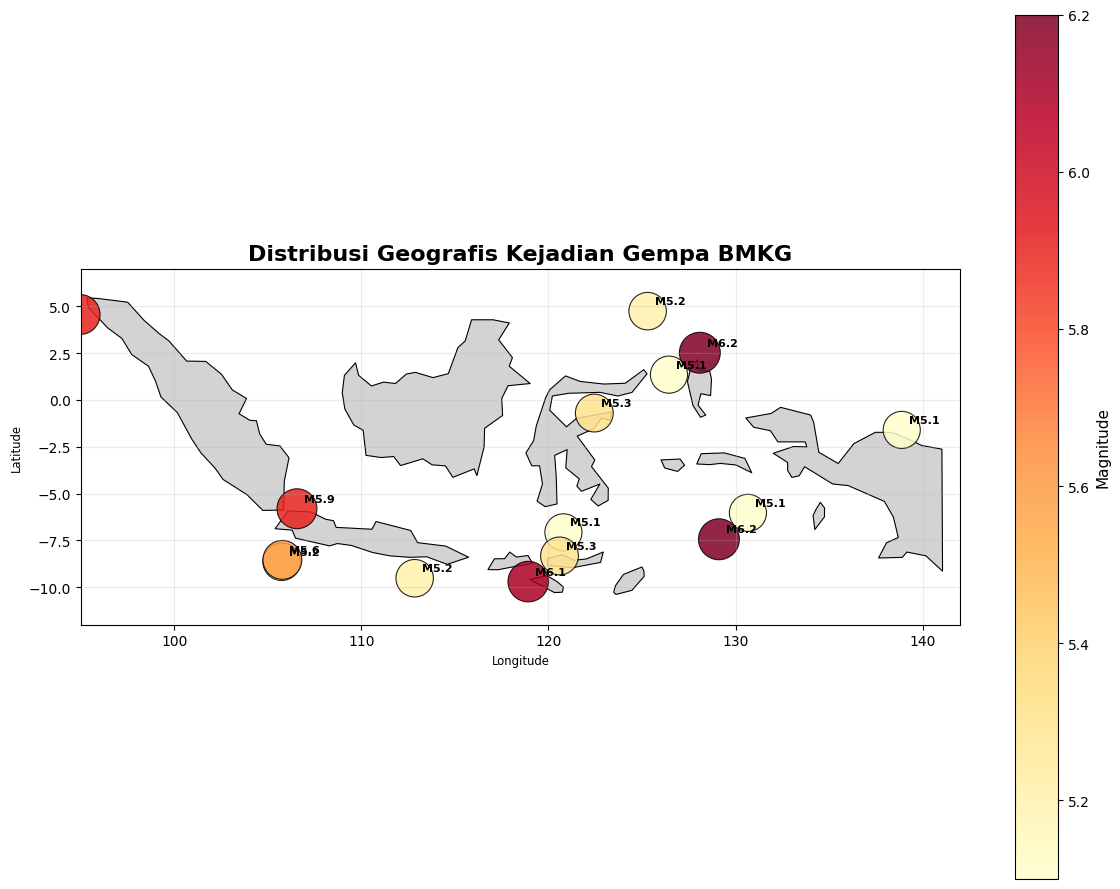

In [26]:
# ============================================
# BQ3 — COLORED GEOSPATIAL VISUALIZATION
# ============================================

import geopandas as gpd
import matplotlib.pyplot as plt

# Load world map
world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
)

# Select Indonesia
indonesia = world[world["NAME"] == "Indonesia"]

# Create figure
fig, ax = plt.subplots(figsize=(12, 9))

# Indonesia map
indonesia.plot(
    ax=ax,
    color="lightgray",
    edgecolor="black",
    linewidth=0.8
)

# Earthquake points
scatter = ax.scatter(
    df_clean["Longitude"],
    df_clean["Latitude"],
    c=df_clean["Magnitude"],
    cmap="YlOrRd",
    s=df_clean["Magnitude"] * 140,
    alpha=0.85,
    edgecolors="black",
    linewidths=0.8
)

# Add magnitude labels
for _, row in df_clean.iterrows():
    ax.annotate(
        f"M{row['Magnitude']:.1f}",
        (row["Longitude"], row["Latitude"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
        fontweight="bold"
    )

# Colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Magnitude", fontsize=11)

# Focus on Indonesia
ax.set_xlim(95, 142)
ax.set_ylim(-12, 7)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

ax.set_title(
    "Distribusi Geografis Kejadian Gempa BMKG",
    fontsize=16,
    fontweight="bold"
)

ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

## BQ3 — Regional Analysis

Kolom `Wilayah` dari BMKG berisi deskripsi lokasi dalam bentuk teks, sehingga nilai uniknya sangat spesifik, misalnya jarak dan arah dari suatu lokasi.

Untuk melakukan analisis regional, informasi lokasi tersebut dikelompokkan menjadi kategori region yang lebih umum berdasarkan informasi wilayah yang terdapat pada teks `Wilayah`.

Kategori region digunakan untuk membandingkan jumlah kejadian, rata-rata magnitudo, dan rata-rata kedalaman gempa.

> Catatan: kategori region merupakan hasil transformasi untuk kebutuhan analisis dan bukan kolom asli dari dataset BMKG.

In [27]:
# ============================================
# BQ3 — REGIONAL CLASSIFICATION
# ============================================

def classify_region(wilayah):

    wilayah = wilayah.upper()

    if "SULUT" in wilayah:
        return "Sulawesi Utara"

    elif "SULTENG" in wilayah:
        return "Sulawesi Tengah"

    elif "MANGGARAI" in wilayah or "CILACAP" in wilayah:
        if "MANGGARAI" in wilayah:
            return "Nusa Tenggara Timur"
        else:
            return "Jawa Tengah"

    elif "PAPUA" in wilayah:
        return "Papua"

    elif "BANTEN" in wilayah:
        return "Banten"

    elif "MALUT" in wilayah:
        return "Maluku Utara"

    elif "MALUKUBRTDAYA" in wilayah or "TANIMBAR" in wilayah:
        return "Maluku"

    elif "MALANG" in wilayah:
        return "Jawa Timur"

    elif "KEPSERIBU" in wilayah:
        return "DKI Jakarta"

    elif "PULAUPUAH" in wilayah:
        return "Sulawesi Tengah"

    else:
        return "Lainnya"


df_clean["Region"] = df_clean["Wilayah"].apply(classify_region)

print("=== HASIL KLASIFIKASI REGION ===")

display(
    df_clean[
        ["Wilayah", "Region"]
    ].sort_values("Region")
)

=== HASIL KLASIFIKASI REGION ===


,Wilayah,Region
7,198 km BaratDaya BAYAH-BANTEN,Banten
10,186 km BaratDaya BAYAH-BANTEN,Banten
13,6 km Tenggara KEPSERIBU-DKI,DKI Jakarta
11,156 km Tenggara KAB-MALANG-JATIM,Jawa Timur
0,68 km BaratDaya CALANG-ACEHJAYA,Lainnya
1,14 km BaratDaya KODI-SUMBABARATDAYA-NTT,Lainnya
2,111 km Tenggara SELAYAR-SULSEL,Lainnya
12,227 km BaratLaut TANIMBAR,Maluku
14,166 km TimurLaut MALUKUBRTDAYA,Maluku
8,118 km BaratLaut JAILOLO-MALUT,Maluku Utara


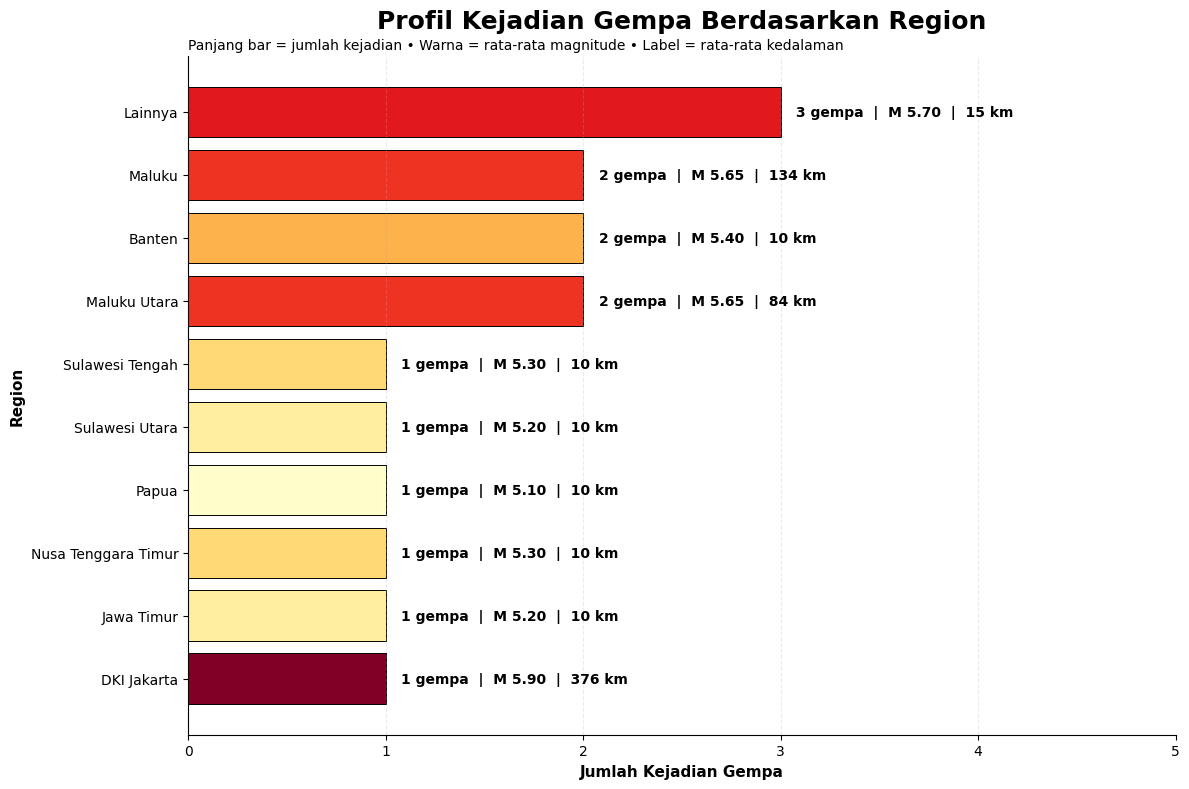

In [28]:
# ============================================
# BQ3 — REGIONAL EARTHQUAKE PROFILE
# ============================================

import matplotlib.pyplot as plt
import matplotlib as mpl

# Aggregate regional data
region_summary = (
    df_clean
    .groupby("Region")
    .agg(
        Jumlah_Gempa=("Magnitude", "count"),
        Rata_Rata_Magnitude=("Magnitude", "mean"),
        Rata_Rata_Kedalaman=("Kedalaman", "mean")
    )
    .sort_values("Jumlah_Gempa", ascending=True)
)

# Create color scale based on average magnitude
norm = mpl.colors.Normalize(
    vmin=region_summary["Rata_Rata_Magnitude"].min(),
    vmax=region_summary["Rata_Rata_Magnitude"].max()
)

cmap = plt.cm.YlOrRd

colors = cmap(
    norm(region_summary["Rata_Rata_Magnitude"])
)

# Create figure
fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(
    region_summary.index,
    region_summary["Jumlah_Gempa"],
    color=colors,
    edgecolor="black",
    linewidth=0.7
)

# Add information to each bar
for bar, (_, row) in zip(
    bars,
    region_summary.iterrows()
):

    ax.text(
        bar.get_width() + 0.08,
        bar.get_y() + bar.get_height() / 2,
        f"{int(row['Jumlah_Gempa'])} gempa  |  "
        f"M {row['Rata_Rata_Magnitude']:.2f}  |  "
        f"{row['Rata_Rata_Kedalaman']:.0f} km",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

# Title
ax.set_title(
    "Profil Kejadian Gempa Berdasarkan Region",
    fontsize=18,
    fontweight="bold",
    pad=20
)

ax.text(
    0,
    1.01,
    "Panjang bar = jumlah kejadian • Warna = rata-rata magnitude • Label = rata-rata kedalaman",
    transform=ax.transAxes,
    fontsize=10
)

# Axis labels
ax.set_xlabel(
    "Jumlah Kejadian Gempa",
    fontsize=11,
    fontweight="bold"
)

ax.set_ylabel(
    "Region",
    fontsize=11,
    fontweight="bold"
)

# Grid
ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Give labels some space
ax.set_xlim(
    0,
    region_summary["Jumlah_Gempa"].max() + 2
)

plt.tight_layout()
plt.show()

In [30]:
# ============================================
# BQ3 — REGIONAL SUMMARY
# ============================================

region_summary = (
    df_clean
    .groupby("Region")
    .agg(
        Jumlah_Gempa=("Magnitude", "count"),
        Rata_Rata_Magnitude=("Magnitude", "mean"),
        Maksimum_Magnitude=("Magnitude", "max"),
        Rata_Rata_Kedalaman=("Kedalaman", "mean"),
        Kedalaman_Maksimum=("Kedalaman", "max")
    )
    .sort_values(
        "Jumlah_Gempa",
        ascending=False
    )
    .reset_index()
)

print("=== RINGKASAN GEMPA BERDASARKAN REGION ===")

display(
    region_summary.style.format({
        "Rata_Rata_Magnitude": "{:.2f}",
        "Maksimum_Magnitude": "{:.1f}",
        "Rata_Rata_Kedalaman": "{:.1f}",
        "Kedalaman_Maksimum": "{:.0f}"
    })
)

=== RINGKASAN GEMPA BERDASARKAN REGION ===


,Region,Jumlah_Gempa,Rata_Rata_Magnitude,Maksimum_Magnitude,Rata_Rata_Kedalaman,Kedalaman_Maksimum
0,Lainnya,3,5.70,6.1,15.3,26
1,Banten,2,5.40,5.6,10.0,10
2,Maluku Utara,2,5.65,6.2,84.5,145
3,Maluku,2,5.65,6.2,133.5,143
4,DKI Jakarta,1,5.90,5.9,376.0,376
5,Jawa Timur,1,5.20,5.2,10.0,10
6,Nusa Tenggara Timur,1,5.30,5.3,10.0,10
7,Papua,1,5.10,5.1,10.0,10
8,Sulawesi Tengah,1,5.30,5.3,10.0,10
9,Sulawesi Utara,1,5.20,5.2,10.0,10


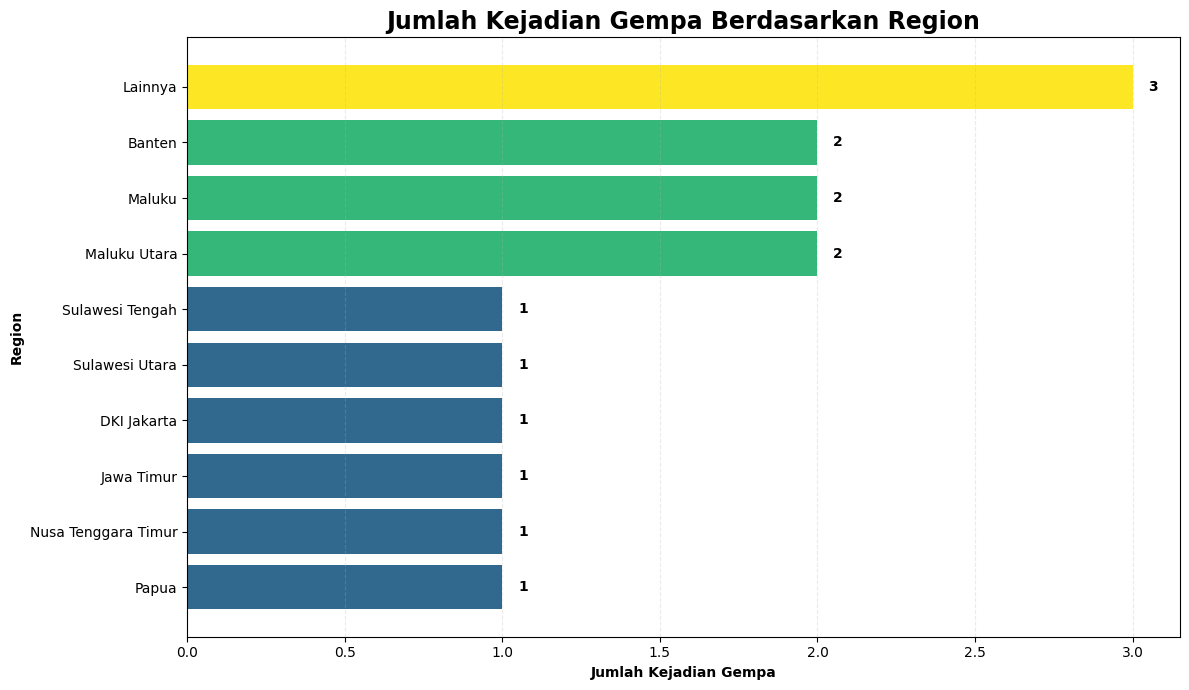

In [31]:
# ============================================
# BQ3 — REGIONAL COMPARISON
# ============================================

plt.figure(figsize=(12, 7))

plot_data = region_summary.sort_values(
    "Jumlah_Gempa",
    ascending=True
)

bars = plt.barh(
    plot_data["Region"],
    plot_data["Jumlah_Gempa"],
    color=plt.cm.viridis(
        plot_data["Jumlah_Gempa"] /
        plot_data["Jumlah_Gempa"].max()
    )
)

for bar, count in zip(
    bars,
    plot_data["Jumlah_Gempa"]
):
    plt.text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        str(count),
        va="center",
        fontweight="bold"
    )

plt.title(
    "Jumlah Kejadian Gempa Berdasarkan Region",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel(
    "Jumlah Kejadian Gempa",
    fontweight="bold"
)

plt.ylabel(
    "Region",
    fontweight="bold"
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

plt.tight_layout()
plt.show()

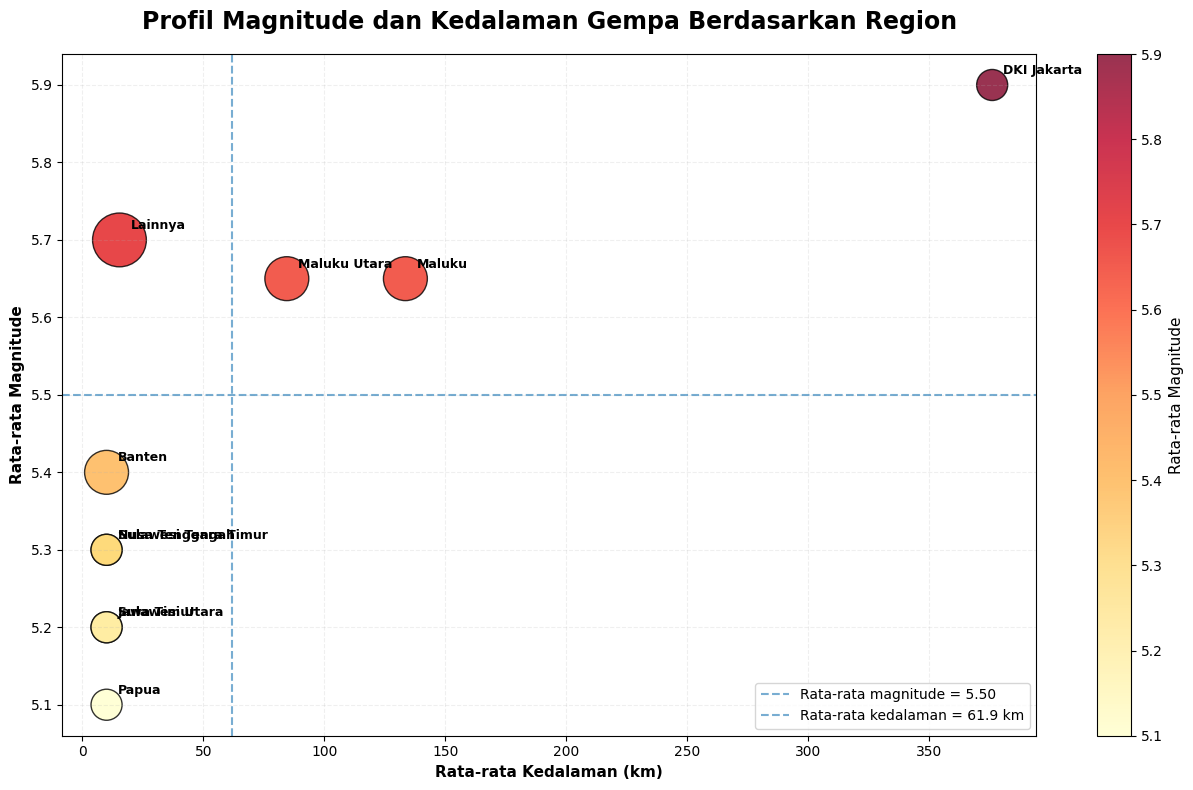

In [32]:
# ============================================
# BQ3 — REGIONAL MAGNITUDE vs DEPTH
# ============================================

region_profile = (
    df_clean
    .groupby("Region")
    .agg(
        Jumlah_Gempa=("Magnitude", "count"),
        Rata_Rata_Magnitude=("Magnitude", "mean"),
        Rata_Rata_Kedalaman=("Kedalaman", "mean")
    )
    .reset_index()
)

plt.figure(figsize=(13, 8))

scatter = plt.scatter(
    region_profile["Rata_Rata_Kedalaman"],
    region_profile["Rata_Rata_Magnitude"],
    s=region_profile["Jumlah_Gempa"] * 500,
    c=region_profile["Rata_Rata_Magnitude"],
    cmap="YlOrRd",
    alpha=0.8,
    edgecolors="black",
    linewidths=1
)

# Add region labels
for _, row in region_profile.iterrows():

    plt.annotate(
        row["Region"],
        (
            row["Rata_Rata_Kedalaman"],
            row["Rata_Rata_Magnitude"]
        ),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=9,
        fontweight="bold"
    )

# Average reference lines
overall_magnitude = df_clean["Magnitude"].mean()
overall_depth = df_clean["Kedalaman"].mean()

plt.axhline(
    overall_magnitude,
    linestyle="--",
    linewidth=1.5,
    alpha=0.6,
    label=f"Rata-rata magnitude = {overall_magnitude:.2f}"
)

plt.axvline(
    overall_depth,
    linestyle="--",
    linewidth=1.5,
    alpha=0.6,
    label=f"Rata-rata kedalaman = {overall_depth:.1f} km"
)

# Colorbar
cbar = plt.colorbar(scatter)
cbar.set_label(
    "Rata-rata Magnitude",
    fontsize=11
)

# Titles
plt.title(
    "Profil Magnitude dan Kedalaman Gempa Berdasarkan Region",
    fontsize=17,
    fontweight="bold",
    pad=18
)

plt.xlabel(
    "Rata-rata Kedalaman (km)",
    fontsize=11,
    fontweight="bold"
)

plt.ylabel(
    "Rata-rata Magnitude",
    fontsize=11,
    fontweight="bold"
)

plt.grid(
    alpha=0.2,
    linestyle="--"
)

plt.legend(
    loc="best",
    frameon=True
)

plt.tight_layout()
plt.show()

### Interpretasi BQ3

Analisis regional dilakukan dengan mengelompokkan informasi lokasi pada kolom `Wilayah` menjadi beberapa kategori `Region`. Pengelompokan ini digunakan untuk membandingkan jumlah kejadian, rata-rata magnitude, dan rata-rata kedalaman antar kelompok wilayah.

Hasil analisis menunjukkan bahwa karakteristik gempa pada dataset tidak sepenuhnya seragam antar region. Perbedaan dapat dilihat dari jumlah kejadian maupun nilai rata-rata magnitude dan kedalaman.

Visualisasi profil region membantu melihat tiga informasi sekaligus, yaitu **jumlah kejadian gempa**, **rata-rata magnitude**, dan **rata-rata kedalaman**. Dengan demikian, region dengan jumlah kejadian yang lebih banyak dapat dibandingkan dengan region yang memiliki karakteristik magnitude atau kedalaman yang berbeda.

Selain itu, visualisasi magnitude dan kedalaman berdasarkan region menunjukkan bahwa beberapa region memiliki rata-rata kedalaman yang lebih tinggi dibandingkan region lainnya. Hal ini memperlihatkan adanya variasi karakteristik lokasi kejadian gempa dalam dataset.

Namun, hasil perbandingan antarwilayah perlu diinterpretasikan secara hati-hati karena jumlah observasi hanya **15 kejadian** dan pengelompokan `Region` merupakan hasil transformasi dari teks lokasi BMKG, bukan kategori region yang secara langsung diberikan oleh dataset asli.

Dengan demikian, BQ3 menunjukkan bahwa terdapat **perbedaan karakteristik gempa antar kelompok wilayah** dalam dataset yang dianalisis, tetapi hasil ini bersifat eksploratif dan belum dapat digunakan untuk menyimpulkan pola gempa seluruh wilayah Indonesia.

In [33]:
# ============================================
# BQ4 — AI ANOMALY DETECTION
# ============================================

from sklearn.ensemble import IsolationForest

# Features used for anomaly detection
features = df_clean[
    ["Magnitude", "Kedalaman"]
].copy()

# Create Isolation Forest model
model = IsolationForest(
    n_estimators=200,
    contamination=0.20,
    random_state=42
)

# Train model and predict
df_clean["Anomaly"] = model.fit_predict(features)

# Convert model output into readable labels
df_clean["Status_Anomaly"] = df_clean["Anomaly"].map({
    1: "Normal",
    -1: "Anomaly"
})

print("=== HASIL ANOMALY DETECTION ===")

display(
    df_clean[
        [
            "DateTime",
            "Magnitude",
            "Kedalaman",
            "Wilayah",
            "Status_Anomaly"
        ]
    ].sort_values(
        "Status_Anomaly"
    )
)

=== HASIL ANOMALY DETECTION ===


,DateTime,Magnitude,Kedalaman,Wilayah,Status_Anomaly
9,2026-09-14 10:58:04+00:00,6.2,145.0,42 km TimurLaut PULAUDOI-MALUT,Anomaly
12,2026-09-12 06:14:33+00:00,5.1,124.0,227 km BaratLaut TANIMBAR,Anomaly
13,2026-09-11 21:23:56+00:00,5.9,376.0,6 km Tenggara KEPSERIBU-DKI,Anomaly
0,2026-10-03 23:37:31+00:00,5.9,26.0,68 km BaratDaya CALANG-ACEHJAYA,Normal
1,2026-10-03 22:55:52+00:00,6.1,10.0,14 km BaratDaya KODI-SUMBABARATDAYA-NTT,Normal
2,2026-10-01 14:20:00+00:00,5.1,10.0,111 km Tenggara SELAYAR-SULSEL,Normal
3,2026-09-21 23:48:13+00:00,5.2,10.0,127 km BaratLaut TAHUNA-KEP.SANGIHE-SULUT,Normal
4,2026-09-21 07:31:07+00:00,5.3,10.0,26 km BaratDaya PULAUPUAH-SULTENG,Normal
5,2026-09-21 01:41:37+00:00,5.3,10.0,34 km TimurLaut RUTENG-MANGGARAI-NTT,Normal
6,2026-09-19 04:18:36+00:00,5.1,10.0,33 km TimurLaut SARMI-PAPUA,Normal


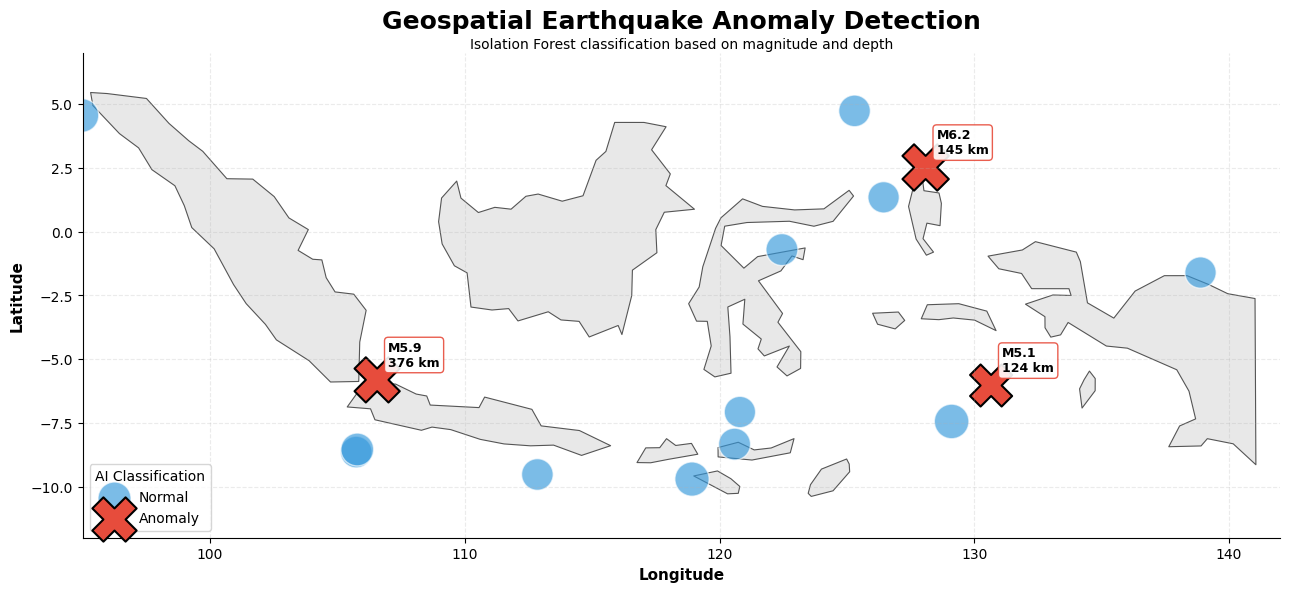

In [34]:
# ============================================
# BQ4 — GEOSPATIAL ANOMALY MAP
# ============================================

import geopandas as gpd
import matplotlib.pyplot as plt

# Load world map
world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
)

# Select Indonesia
indonesia = world[world["NAME"] == "Indonesia"]

# Create figure
fig, ax = plt.subplots(figsize=(13, 9))

# Indonesia background
indonesia.plot(
    ax=ax,
    color="#E8E8E8",
    edgecolor="#555555",
    linewidth=0.8
)

# Separate normal and anomaly
normal = df_clean[
    df_clean["Status_Anomaly"] == "Normal"
]

anomaly = df_clean[
    df_clean["Status_Anomaly"] == "Anomaly"
]

# --------------------------------------------
# NORMAL EARTHQUAKES
# --------------------------------------------

ax.scatter(
    normal["Longitude"],
    normal["Latitude"],
    s=normal["Magnitude"] * 100,
    color="#3498DB",
    alpha=0.65,
    edgecolors="white",
    linewidths=1,
    label="Normal"
)

# --------------------------------------------
# ANOMALY EARTHQUAKES
# --------------------------------------------

ax.scatter(
    anomaly["Longitude"],
    anomaly["Latitude"],
    s=anomaly["Magnitude"] * 180,
    color="#E74C3C",
    marker="X",
    alpha=1,
    edgecolors="black",
    linewidths=1.5,
    label="Anomaly"
)

# --------------------------------------------
# LABEL ANOMALIES
# --------------------------------------------

for _, row in anomaly.iterrows():

    ax.annotate(
        f"M{row['Magnitude']:.1f}\n"
        f"{row['Kedalaman']:.0f} km",
        (
            row["Longitude"],
            row["Latitude"]
        ),
        xytext=(8, 10),
        textcoords="offset points",
        fontsize=9,
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            edgecolor="#E74C3C",
            alpha=0.9
        )
    )

# --------------------------------------------
# MAP SETTINGS
# --------------------------------------------

ax.set_xlim(95, 142)
ax.set_ylim(-12, 7)

ax.set_xlabel(
    "Longitude",
    fontsize=11,
    fontweight="bold"
)

ax.set_ylabel(
    "Latitude",
    fontsize=11,
    fontweight="bold"
)

ax.set_title(
    "Geospatial Earthquake Anomaly Detection",
    fontsize=18,
    fontweight="bold",
    pad=18
)

ax.text(
    0.5,
    1.01,
    "Isolation Forest classification based on magnitude and depth",
    transform=ax.transAxes,
    ha="center",
    fontsize=10
)

# Grid
ax.grid(
    linestyle="--",
    alpha=0.25
)

# Legend
ax.legend(
    title="AI Classification",
    fontsize=10,
    title_fontsize=10,
    loc="lower left"
)

# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [35]:
# ============================================
# BQ4 — ANOMALY SUMMARY TABLE
# ============================================

# Select only anomalous observations
anomaly_summary = (
    df_clean[
        df_clean["Status_Anomaly"] == "Anomaly"
    ][
        [
            "DateTime",
            "Magnitude",
            "Kedalaman",
            "Latitude",
            "Longitude",
            "Wilayah",
            "Potensi"
        ]
    ]
    .sort_values(
        ["Magnitude", "Kedalaman"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

print("=== RINGKASAN GEMPA YANG TERDETEKSI SEBAGAI ANOMALY ===")

print(
    f"Jumlah anomaly: {len(anomaly_summary)} dari {len(df_clean)} kejadian"
)

print(
    f"Persentase anomaly: "
    f"{len(anomaly_summary) / len(df_clean) * 100:.1f}%"
)

display(anomaly_summary)

=== RINGKASAN GEMPA YANG TERDETEKSI SEBAGAI ANOMALY ===
Jumlah anomaly: 3 dari 15 kejadian
Persentase anomaly: 20.0%


,DateTime,Magnitude,Kedalaman,Latitude,Longitude,Wilayah,Potensi
0,2026-09-14 10:58:04+00:00,6.2,145.0,2.52,128.09,42 km TimurLaut PULAUDOI-MALUT,Tidak berpotensi tsunami
1,2026-09-11 21:23:56+00:00,5.9,376.0,-5.81,106.56,6 km Tenggara KEPSERIBU-DKI,Tidak berpotensi tsunami
2,2026-09-12 06:14:33+00:00,5.1,124.0,-6.03,130.66,227 km BaratLaut TANIMBAR,Tidak berpotensi tsunami


In [36]:
# ============================================
# BQ4 — MODEL SUMMARY
# ============================================

total_events = len(df_clean)

normal_count = (
    df_clean["Status_Anomaly"] == "Normal"
).sum()

anomaly_count = (
    df_clean["Status_Anomaly"] == "Anomaly"
).sum()

print("============================================")
print("ISOLATION FOREST SUMMARY")
print("============================================")

print(f"Total kejadian : {total_events}")
print(f"Normal         : {normal_count}")
print(f"Anomaly        : {anomaly_count}")

print(
    f"Persentase anomaly : "
    f"{anomaly_count / total_events * 100:.1f}%"
)

print("\n=== KARAKTERISTIK ANOMALY ===")

if anomaly_count > 0:

    print(
        f"Range magnitude anomaly : "
        f"{anomaly_summary['Magnitude'].min():.1f} – "
        f"{anomaly_summary['Magnitude'].max():.1f}"
    )

    print(
        f"Range kedalaman anomaly : "
        f"{anomaly_summary['Kedalaman'].min():.0f} – "
        f"{anomaly_summary['Kedalaman'].max():.0f} km"
    )

else:

    print("Tidak terdapat anomaly yang terdeteksi.")

ISOLATION FOREST SUMMARY
Total kejadian : 15
Normal         : 12
Anomaly        : 3
Persentase anomaly : 20.0%

=== KARAKTERISTIK ANOMALY ===
Range magnitude anomaly : 5.1 – 6.2
Range kedalaman anomaly : 124 – 376 km


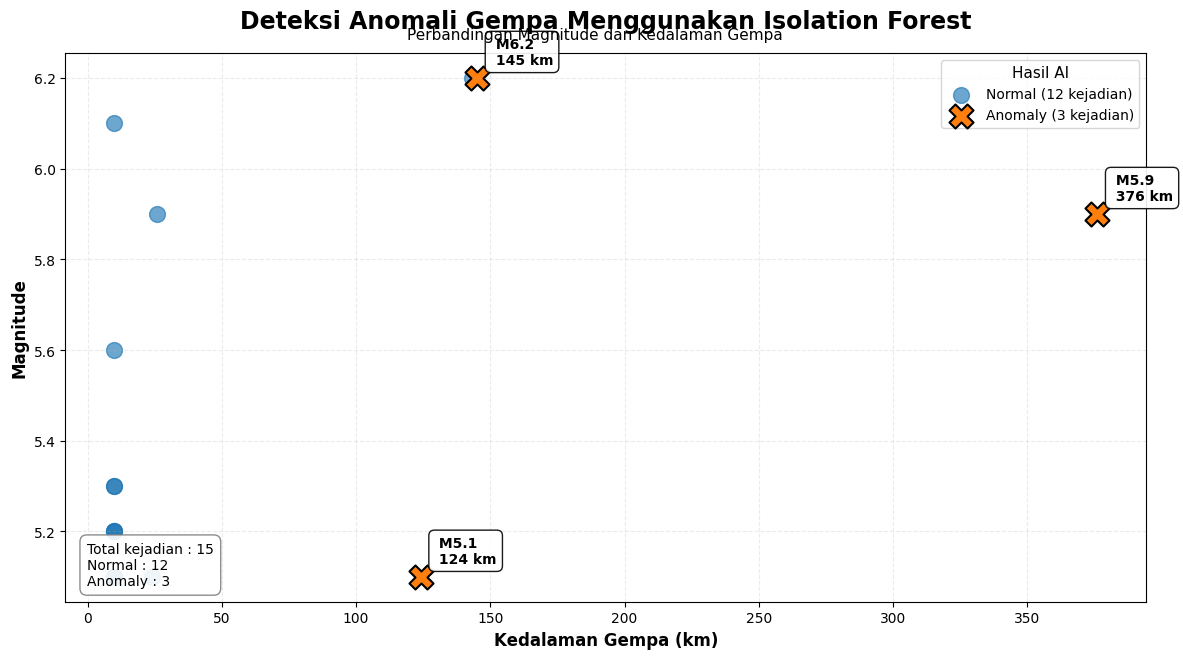

In [38]:
# ============================================
# BQ4 — AI ANOMALY VISUALIZATION
# ============================================

import matplotlib.pyplot as plt

# Pisahkan data
normal = df_clean[
    df_clean["Status_Anomaly"] == "Normal"
]

anomaly = df_clean[
    df_clean["Status_Anomaly"] == "Anomaly"
]

# ============================================
# CREATE FIGURE
# ============================================

plt.figure(figsize=(12, 7))

# --------------------------------------------
# NORMAL DATA
# --------------------------------------------

plt.scatter(
    normal["Kedalaman"],
    normal["Magnitude"],
    s=130,
    alpha=0.65,
    label=f"Normal ({len(normal)} kejadian)"
)

# --------------------------------------------
# ANOMALY DATA
# --------------------------------------------

plt.scatter(
    anomaly["Kedalaman"],
    anomaly["Magnitude"],
    s=300,
    marker="X",
    alpha=1,
    edgecolors="black",
    linewidths=1.5,
    label=f"Anomaly ({len(anomaly)} kejadian)"
)

# --------------------------------------------
# LABEL ANOMALY
# --------------------------------------------

for _, row in anomaly.iterrows():

    plt.annotate(
        f" M{row['Magnitude']:.1f}\n"
        f" {row['Kedalaman']:.0f} km",

        (
            row["Kedalaman"],
            row["Magnitude"]
        ),

        xytext=(10, 10),
        textcoords="offset points",

        fontsize=10,
        fontweight="bold",

        bbox=dict(
            boxstyle="round,pad=0.4",
            facecolor="white",
            edgecolor="black",
            alpha=0.9
        )
    )

# ============================================
# TITLES
# ============================================

plt.title(
    "Deteksi Anomali Gempa Menggunakan Isolation Forest",
    fontsize=17,
    fontweight="bold",
    pad=18
)

plt.suptitle(
    "Perbandingan Magnitude dan Kedalaman Gempa",
    fontsize=11,
    y=0.91
)

# ============================================
# AXIS
# ============================================

plt.xlabel(
    "Kedalaman Gempa (km)",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Magnitude",
    fontsize=12,
    fontweight="bold"
)

# ============================================
# GRID
# ============================================

plt.grid(
    linestyle="--",
    alpha=0.25
)

# ============================================
# LEGEND
# ============================================

plt.legend(
    title="Hasil AI",
    fontsize=10,
    title_fontsize=11,
    loc="best"
)

# ============================================
# INFORMATION BOX
# ============================================

plt.text(
    0.02,
    0.03,

    f"Total kejadian : {len(df_clean)}\n"
    f"Normal : {len(normal)}\n"
    f"Anomaly : {len(anomaly)}",

    transform=plt.gca().transAxes,

    fontsize=10,

    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="white",
        edgecolor="gray",
        alpha=0.9
    )
)

# ============================================
# FINAL
# ============================================

plt.tight_layout()
plt.show()

## Interpretasi BQ4 — AI Anomaly Detection

Isolation Forest digunakan untuk mengidentifikasi kejadian gempa yang memiliki karakteristik berbeda dibandingkan pola umum pada dataset berdasarkan dua variabel, yaitu magnitude dan kedalaman.

Hasil model membagi kejadian gempa menjadi dua kelompok, yaitu **Normal** dan **Anomaly**. Kejadian yang dikategorikan sebagai anomaly merupakan observasi yang memiliki kombinasi magnitude dan kedalaman yang relatif tidak umum dibandingkan observasi lainnya.

Hasil ini tidak berarti bahwa gempa tersebut salah atau tidak valid. Anomaly hanya menunjukkan bahwa karakteristik gempa tersebut berbeda dari pola mayoritas data yang dianalisis.

Visualisasi scatter plot menunjukkan posisi anomaly berdasarkan hubungan antara magnitude dan kedalaman, sedangkan peta geospasial menunjukkan lokasi kejadian anomaly.

Dengan demikian, Isolation Forest dapat digunakan sebagai pendekatan awal untuk membantu mengidentifikasi kejadian gempa yang perlu mendapatkan perhatian lebih lanjut dalam proses eksplorasi data.

In [39]:
# ============================================
# BQ4 — AI INSIGHT
# ============================================

print("=== AI INSIGHT ===")

if anomaly_count > 0:

    print(
        f"Model mendeteksi {anomaly_count} dari "
        f"{total_events} kejadian sebagai anomaly."
    )

    print(
        f"Persentase anomaly: "
        f"{anomaly_count / total_events * 100:.1f}%"
    )

    print("\nKejadian anomaly memiliki karakteristik:")

    print(
        f"- Magnitude: "
        f"{anomaly_summary['Magnitude'].min():.1f} "
        f"sampai "
        f"{anomaly_summary['Magnitude'].max():.1f}"
    )

    print(
        f"- Kedalaman: "
        f"{anomaly_summary['Kedalaman'].min():.0f} "
        f"sampai "
        f"{anomaly_summary['Kedalaman'].max():.0f} km"
    )

    print("\nKesimpulan:")
    print(
        "Kejadian yang ditandai sebagai anomaly memiliki "
        "kombinasi magnitude dan kedalaman yang relatif "
        "berbeda dari pola mayoritas dataset."
    )

else:

    print(
        "Tidak terdapat anomaly yang terdeteksi."
    )

=== AI INSIGHT ===
Model mendeteksi 3 dari 15 kejadian sebagai anomaly.
Persentase anomaly: 20.0%

Kejadian anomaly memiliki karakteristik:
- Magnitude: 5.1 sampai 6.2
- Kedalaman: 124 sampai 376 km

Kesimpulan:
Kejadian yang ditandai sebagai anomaly memiliki kombinasi magnitude dan kedalaman yang relatif berbeda dari pola mayoritas dataset.


### Interpretasi Hasil AI

Isolation Forest mengidentifikasi **3 dari 15 kejadian gempa (20,0%)** sebagai anomaly berdasarkan kombinasi variabel magnitude dan kedalaman.

Kejadian yang terdeteksi sebagai anomaly memiliki rentang magnitude **5,1–6,2** dan kedalaman **124–376 km**. Hasil tersebut tidak berarti bahwa gempa dengan magnitude atau kedalaman tersebut secara otomatis merupakan kejadian abnormal secara ilmiah.

Anomaly detection pada analisis ini digunakan untuk menemukan observasi yang memiliki karakteristik relatif berbeda dibandingkan dengan pola mayoritas data. Model mempertimbangkan kombinasi magnitude dan kedalaman dalam menentukan observasi yang memiliki pola berbeda.

Dengan demikian, hasil Isolation Forest digunakan sebagai **alat bantu eksplorasi data**, bukan sebagai metode untuk menentukan apakah suatu kejadian gempa valid atau tidak valid.

Karena dataset hanya terdiri dari **15 observasi**, hasil anomaly detection perlu dipandang sebagai analisis awal dan tidak digunakan sebagai model prediksi operasional.

## Overall Findings

Berdasarkan seluruh proses data wrangling, data cleaning, exploratory data analysis, visualisasi, dan machine learning terhadap data gempa BMKG, terdapat beberapa temuan utama.

### 1. Karakteristik Magnitude

Dataset terdiri dari **15 kejadian gempa** dengan magnitude antara **5,1 hingga 6,2**. Nilai rata-rata magnitude adalah **5,50**, sedangkan median sebesar **5,3**.

Magnitude yang paling sering muncul adalah **5,1**, yaitu sebanyak **4 kejadian**. Selain itu, terdapat **2 kejadian dengan magnitude 6,2** yang menjadi nilai maksimum dalam dataset.

Secara umum, data didominasi oleh gempa dengan magnitude pada kisaran **5,1–5,3**, tetapi terdapat beberapa kejadian dengan magnitude yang lebih tinggi.

### 2. Hubungan Magnitude dan Kedalaman

Analisis korelasi menunjukkan adanya hubungan positif antara kedalaman dan magnitude.

Nilai **Pearson correlation sebesar 0,469**, sedangkan **Spearman correlation sebesar 0,411**. Kedua nilai tersebut menunjukkan adanya hubungan positif dengan kekuatan sedang dalam dataset yang dianalisis.

Namun, hasil korelasi perlu diinterpretasikan secara hati-hati karena dataset hanya terdiri dari **15 observasi** dan terdapat beberapa nilai kedalaman yang relatif ekstrem.

Hubungan tersebut menunjukkan pola pada data, tetapi **tidak dapat digunakan untuk menyimpulkan hubungan sebab-akibat** antara kedalaman dan magnitude.

### 3. Perbedaan Berdasarkan Region

Analisis regional menunjukkan adanya variasi karakteristik gempa berdasarkan kelompok region yang dibentuk dari informasi lokasi BMKG.

Perbedaan dapat dilihat dari **jumlah kejadian, rata-rata magnitude, dan rata-rata kedalaman** antarregion.

Analisis ini membantu menunjukkan bahwa karakteristik kejadian gempa pada dataset tidak sepenuhnya seragam berdasarkan kelompok wilayah yang dianalisis.

### 4. Anomaly Detection

Isolation Forest mengidentifikasi **3 dari 15 kejadian (20,0%)** sebagai anomaly berdasarkan kombinasi magnitude dan kedalaman.

Kejadian yang ditandai sebagai anomaly memiliki karakteristik yang relatif berbeda dibandingkan pola mayoritas data.

Hasil anomaly detection digunakan sebagai **alat bantu eksplorasi** untuk menemukan observasi yang menarik untuk diperiksa lebih lanjut, bukan untuk menentukan bahwa suatu kejadian gempa merupakan data yang salah atau tidak valid.

### Kesimpulan Umum

Secara keseluruhan, analisis menunjukkan bahwa data gempa BMKG dalam dataset ini memiliki variasi dari sisi **magnitude, kedalaman, dan lokasi**. Kombinasi statistik deskriptif, analisis korelasi, analisis regional, visualisasi, dan machine learning memberikan beberapa sudut pandang untuk memahami karakteristik data gempa.

Namun, seluruh temuan masih bersifat **eksploratif** karena dataset yang digunakan hanya terdiri dari 15 kejadian dan merupakan data gempa terkini pada saat pengambilan data.

## Conclusion

Berdasarkan hasil data wrangling, data cleaning, exploratory data analysis (EDA), visualisasi, analisis regional, dan anomaly detection, dapat disimpulkan bahwa data gempa BMKG pada dataset yang digunakan memiliki variasi dari sisi magnitude, kedalaman, dan lokasi.

Pada **BQ1**, dataset terdiri dari **15 kejadian gempa** dengan magnitude antara **5,1 hingga 6,2**. Rata-rata magnitude adalah **5,50**, median sebesar **5,3**, dan magnitude yang paling sering muncul adalah **5,1** sebanyak **4 kejadian**. Hal ini menunjukkan bahwa dataset didominasi oleh gempa dengan magnitude pada kisaran **5,1–5,3**, meskipun terdapat beberapa kejadian dengan magnitude yang lebih tinggi.

Pada **BQ2**, terdapat hubungan positif antara kedalaman dan magnitude. Nilai korelasi Pearson sebesar **0,469**, sedangkan Spearman sebesar **0,411**. Hasil tersebut menunjukkan adanya pola hubungan positif dengan kekuatan sedang, tetapi tidak dapat digunakan untuk menyimpulkan hubungan sebab-akibat. Hasil korelasi juga perlu diinterpretasikan secara hati-hati karena dataset hanya terdiri dari 15 observasi.

Pada **BQ3**, analisis regional menunjukkan adanya perbedaan karakteristik kejadian gempa berdasarkan kelompok wilayah yang dibentuk dari informasi lokasi BMKG. Perbedaan tersebut dapat dilihat dari jumlah kejadian, rata-rata magnitude, dan rata-rata kedalaman pada masing-masing kelompok region.

Pada **BQ4**, metode Isolation Forest mengidentifikasi **3 dari 15 kejadian atau 20,0%** sebagai anomaly berdasarkan kombinasi magnitude dan kedalaman. Hasil ini digunakan sebagai pendekatan awal untuk menemukan observasi yang memiliki karakteristik relatif berbeda dari pola mayoritas data, bukan untuk menentukan bahwa kejadian tersebut merupakan data yang salah atau tidak valid.

Secara keseluruhan, analisis menunjukkan bahwa pendekatan data science dapat digunakan untuk memahami karakteristik dan pola awal pada data gempa BMKG melalui kombinasi **statistik deskriptif, analisis korelasi, analisis regional, visualisasi, SQL, dan machine learning**.

Namun, karena dataset yang digunakan hanya terdiri dari **15 kejadian gempa**, hasil analisis bersifat **eksploratif** dan belum dapat digeneralisasikan untuk menggambarkan seluruh kejadian gempa di Indonesia.

## Limitations

Analisis ini memiliki beberapa keterbatasan yang perlu diperhatikan.

### 1. Jumlah Data Relatif Kecil

Dataset yang dianalisis hanya terdiri dari **15 kejadian gempa**. Jumlah observasi yang kecil menyebabkan hasil statistik, korelasi, dan machine learning belum dapat digeneralisasikan untuk seluruh kejadian gempa di Indonesia.

### 2. Periode Data Terbatas

Dataset BMKG yang digunakan merupakan data gempa terkini pada saat proses pengambilan data. Dataset ini belum merepresentasikan data historis dalam periode yang panjang.

### 3. Anomaly Detection Bersifat Relatif

Hasil Isolation Forest bergantung pada pola data yang digunakan. Observasi yang ditandai sebagai anomaly merupakan observasi yang memiliki karakteristik relatif berbeda dibandingkan mayoritas data dalam dataset, bukan berarti kejadian tersebut merupakan gempa yang tidak valid.

### 4. Korelasi Tidak Menunjukkan Sebab-Akibat

Hubungan antara kedalaman dan magnitude yang ditemukan melalui analisis korelasi hanya menunjukkan pola hubungan dalam dataset. Hasil tersebut tidak dapat digunakan untuk menyimpulkan hubungan sebab-akibat.

### 5. Pengelompokan Region

Pengelompokan region pada analisis BQ3 dilakukan berdasarkan informasi teks pada kolom `Wilayah` BMKG. Oleh karena itu, kategori region yang digunakan merupakan hasil transformasi data untuk kebutuhan analisis dan bukan kategori region yang secara langsung diberikan oleh dataset asli.

### 6. Machine Learning Bersifat Eksploratif

Model Isolation Forest digunakan sebagai pendekatan awal untuk eksplorasi anomaly. Karena jumlah data sangat terbatas, hasil model belum dapat digunakan sebagai sistem prediksi atau deteksi anomaly operasional.

# Database & SQL Analysis

Data gempa BMKG yang telah melalui proses wrangling dan cleaning juga dimasukkan ke dalam database SQLite sebagai bagian dari proses data engineering.

SQLite digunakan dalam notebook ini untuk mendemonstrasikan proses penyimpanan data dan analisis menggunakan query SQL. Selain itu, pipeline Airflow yang telah dibuat menggunakan MySQL sebagai database target pada proses ETL.

Pada bagian ini dilakukan beberapa query SQL untuk memeriksa data dan memperoleh ringkasan karakteristik gempa.

## Struktur Data pada Database

Tabel yang digunakan adalah `earthquake_data`.

Kolom utama pada tabel:

| Kolom | Keterangan |
|---|---|
| `datetime` | Waktu kejadian gempa |
| `magnitude` | Magnitude gempa |
| `depth_km` | Kedalaman gempa dalam kilometer |
| `latitude` | Koordinat lintang |
| `longitude` | Koordinat bujur |
| `region` | Wilayah kejadian gempa |
| `potential` | Informasi potensi tsunami |

In [40]:
# ============================================
# DATABASE — LOAD DATA KE SQLITE
# ============================================

import sqlite3

# Membuat database SQLite
conn = sqlite3.connect("bmkg_earthquake.db")

# Menyiapkan data untuk database
df_sql = df_clean[
    [
        "DateTime",
        "Magnitude",
        "Kedalaman",
        "Latitude",
        "Longitude",
        "Wilayah",
        "Potensi"
    ]
].copy()

# Sesuaikan nama kolom dengan database
df_sql = df_sql.rename(columns={
    "DateTime": "datetime",
    "Magnitude": "magnitude",
    "Kedalaman": "depth_km",
    "Latitude": "latitude",
    "Longitude": "longitude",
    "Wilayah": "region",
    "Potensi": "potential"
})

# Load ke database
df_sql.to_sql(
    "earthquake_data",
    conn,
    if_exists="replace",
    index=False
)

print("Data berhasil dimasukkan ke database SQLite.")
print(f"Jumlah data: {len(df_sql)}")

Data berhasil dimasukkan ke database SQLite.
Jumlah data: 15


In [41]:
# ============================================
# SQL — CHECK DATA
# ============================================

query = """
SELECT *
FROM earthquake_data
LIMIT 5;
"""

result_sql = pd.read_sql_query(
    query,
    conn
)

display(result_sql)

,datetime,magnitude,depth_km,latitude,longitude,region,potential
0,2026-10-03 23:37:31+00:00,5.9,26.0,4.56,94.97,68 km BaratDaya CALANG-ACEHJAYA,Tidak berpotensi tsunami
1,2026-10-03 22:55:52+00:00,6.1,10.0,-9.70,118.92,14 km BaratDaya KODI-SUMBABARATDAYA-NTT,Tidak berpotensi tsunami
2,2026-10-01 14:20:00+00:00,5.1,10.0,-7.07,120.80,111 km Tenggara SELAYAR-SULSEL,Tidak berpotensi tsunami
3,2026-09-21 23:48:13+00:00,5.2,10.0,4.74,125.30,127 km BaratLaut TAHUNA-KEP.SANGIHE-SULUT,Tidak berpotensi tsunami
4,2026-09-21 07:31:07+00:00,5.3,10.0,-0.70,122.45,26 km BaratDaya PULAUPUAH-SULTENG,Tidak berpotensi tsunami


In [47]:
# ============================================
# SQL — STATISTIK MAGNITUDE
# ============================================

query = """
SELECT
    COUNT(*) AS jumlah_gempa,
    ROUND(AVG(magnitude), 2) AS rata_rata_magnitude,
    MIN(magnitude) AS magnitude_minimum,
    MAX(magnitude) AS magnitude_maksimum
FROM earthquake_data;
"""

result_sql = pd.read_sql_query(
    query,
    conn
)

display(result_sql)

,jumlah_gempa,rata_rata_magnitude,magnitude_minimum,magnitude_maksimum
0,15,5.5,5.1,6.2


In [48]:
# ============================================
# SQL — GEMPA DENGAN MAGNITUDE TERTINGGI
# ============================================

query = """
SELECT
    datetime,
    magnitude,
    depth_km,
    region
FROM earthquake_data
ORDER BY magnitude DESC
LIMIT 5;
"""

top_earthquakes = pd.read_sql_query(
    query,
    conn
)

display(top_earthquakes)

,datetime,magnitude,depth_km,region
0,2026-09-14 10:58:04+00:00,6.2,145.0,42 km TimurLaut PULAUDOI-MALUT
1,2026-09-11 11:56:24+00:00,6.2,143.0,166 km TimurLaut MALUKUBRTDAYA
2,2026-10-03 22:55:52+00:00,6.1,10.0,14 km BaratDaya KODI-SUMBABARATDAYA-NTT
3,2026-10-03 23:37:31+00:00,5.9,26.0,68 km BaratDaya CALANG-ACEHJAYA
4,2026-09-11 21:23:56+00:00,5.9,376.0,6 km Tenggara KEPSERIBU-DKI
